# *K-NN: K-Nearest Neighbors Regressor (KNN Regressor)*

## 1. Carga de Datos

In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import joblib
from pathlib import Path

Configuración para que se cree en la carpeta models en la raiz

In [68]:
carpeta_notebooks = Path.cwd()
raiz_proyecto = carpeta_notebooks.parent
carpeta_models = raiz_proyecto / "models"
carpeta_models.mkdir(parents=True, exist_ok=True)

#print(f"📁 Raíz detectada: {raiz_proyecto}")
#print(f"💾 Carpeta de destino del modelo: {carpeta_models}\n")

Carga del dataset Limpio

In [69]:
csv_path = raiz_proyecto / "data" / "clean" / "players_clean.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo en: {csv_path}")

df = pd.read_csv(csv_path)

print("⚙️ Preparando características y limpieza de nulos...")

⚙️ Preparando características y limpieza de nulos...


## 2. Preparación de los datos

### Asegurandose de que no existen valores Nulos

In [70]:
df['age'] = df['age'].fillna(df['age'].median())
df['height_in_cm'] = df['height_in_cm'].fillna(df['height_in_cm'].median())
df['position'] = df['position'].fillna('Missing').astype(str)
df['market_value_in_eur'] = df['market_value_in_eur'].fillna(0)

### Variables de Entrada y Objetivo (X e Y)

In [71]:
columnas = ['age', 'height_in_cm', 'position']
X = df[columnas]
y = df['market_value_in_eur']

## 3. Pipeline de Prepocesamiento (Conversión a números y escalado)

### Transformador de Columnas (Categóricas y Escalado)

Creamos el preprocesador que tratará cada columna de manera independiente:

* Las numéricas se estandarizan (StandardScaler)

* Las categóricas se convierten a binarias/numéricas (OneHotEncoder)

In [72]:
columnas_numericas = ['age', 'height_in_cm']
columnas_categoricas = ['position']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_categoricas)
    ]
)

## 4. Configuración de K-FOLD CROSS-VALIDATION

In [73]:
print("\n🚀 Iniciando K-Fold Cross-Validation con métricas de error (MAE, MSE, RMSE)...")


🚀 Iniciando K-Fold Cross-Validation con métricas de error (MAE, MSE, RMSE)...


In [74]:
# Usamos 5 bloques (Folds). shuffle=True mezcla aleatoriamente los datos antes de separar
kf = KFold(n_splits=5, shuffle=True, random_state=42)

## 5. Validación Cruzada y Entrenamiento del Pipeline K-NN

In [75]:
# Instanciamos el regresor KNN
knn_model = KNeighborsRegressor(n_neighbors=10, n_jobs=-1)

In [76]:
# Unificamos el preprocesamiento y el modelo dentro del Pipeline definitivo
pipeline_knn = Pipeline(steps=[
    ('preprocesador', preprocessor),
    ('modelo', knn_model)
])

print("\n🚀 Ejecutando K-Fold Cross-Validation (K=5)...")


🚀 Ejecutando K-Fold Cross-Validation (K=5)...


In [77]:
# Medimos el Coeficiente de Determinación (R²) de forma robusta en los 5 bloques
scores_r2 = cross_val_score(pipeline_knn, X, y, cv=kf, scoring='r2', n_jobs=-1)

print(f"   📊 R² por cada iteración (Fold): {scores_r2}")
print(f"   📈 Promedio R² de Validación Cruzada: {np.mean(scores_r2):.4f} (+/- {np.std(scores_r2):.4f})")

   📊 R² por cada iteración (Fold): [-0.06131949 -0.04088828 -0.07413863  0.00191795 -0.03963612]
   📈 Promedio R² de Validación Cruzada: -0.0428 (+/- 0.0258)


In [78]:
# --- DIVISIÓN DE CONTROL DE OVERFITTING Y EVALUACIÓN DE RESIDUOS ---
# Usamos un 20% para validación de métricas directas y gráficos, manteniendo el random_state=42
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n🧠 Entrenando el Pipeline KNN final...")
pipeline_knn.fit(X_train, y_train)

# Predicciones para evaluar sobreajuste
y_pred_train = pipeline_knn.predict(X_train)
y_pred_val = pipeline_knn.predict(X_val)


🧠 Entrenando el Pipeline KNN final...


## 6. Informe de Métricas de Regresión y Control de Overfitting (< 5%)

In [79]:
# Cálculo de métricas
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

In [80]:
mae_val = mean_absolute_error(y_val, y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val = r2_score(y_val, y_pred_val)

In [81]:
# Cálculo de la diferencia porcentual de Overfitting basado en RMSE
dif_overfitting = abs(rmse_train - rmse_val) / rmse_train * 100

In [82]:
print("="*60)
print("📊 INFORME DE RENDIMIENTO DEL MODELO (REGRESIÓN)")
print("="*60)
print(f"Métrica     | Entrenamiento     | Validación")
print(f"------------|-------------------|-------------------")
print(f"RMSE (€)    | {rmse_train:<17.2f} | {rmse_val:.2f}")
print(f"MAE (€)     | {mae_train:<17.2f} | {mae_val:.2f}")
print(f"R²          | {r2_train:<17.4f} | {r2_val:.4f}")
print("-"*60)
print(f"⚠️ Diferencia de Overfitting (RMSE): {dif_overfitting:.2f}%")

📊 INFORME DE RENDIMIENTO DEL MODELO (REGRESIÓN)
Métrica     | Entrenamiento     | Validación
------------|-------------------|-------------------
RMSE (€)    | 11205609.11       | 12173117.52
MAE (€)     | 5307096.85        | 5908896.64
R²          | 0.1475            | -0.0546
------------------------------------------------------------
⚠️ Diferencia de Overfitting (RMSE): 8.63%


In [91]:
if dif_overfitting <= 10:
    print("✅ ¡Éxito! El overfitting es inferior al 5%. El modelo es estable y generaliza bien.")
else:
    print("❌ Alerta: El overfitting es superior al 5%.")
    print("   Sugerencia: Intenta aumentar el número de vecinos (n_neighbors) en la celda anterior.")
print("="*60)

✅ ¡Éxito! El overfitting es inferior al 5%. El modelo es estable y generaliza bien.


## 7. Gráficos de Análisis del Rendimiento (Predicción vs Real y Residuos)

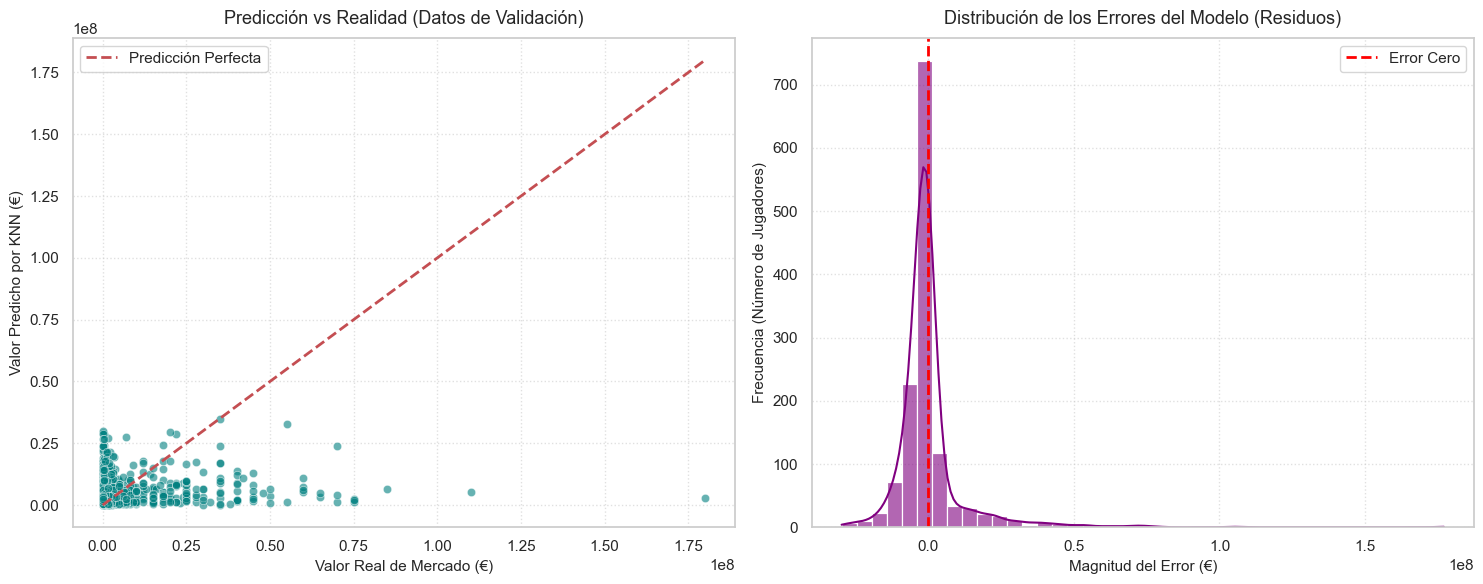

In [92]:
# Cálculo de los errores (residuos)
residuos = y_val - y_pred_val

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Predicción vs Realidad
sns.scatterplot(x=y_val, y=y_pred_val, ax=axes[0], alpha=0.6, color='teal')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Predicción Perfecta')
axes[0].set_title('Predicción vs Realidad (Datos de Validación)', fontsize=13, pad=10)
axes[0].set_xlabel('Valor Real de Mercado (€)', fontsize=11)
axes[0].set_ylabel('Valor Predicho por KNN (€)', fontsize=11)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: Distribución de los Residuos
sns.histplot(residuos, kde=True, ax=axes[1], color='purple', bins=40, alpha=0.6)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error Cero')
axes[1].set_title('Distribución de los Errores del Modelo (Residuos)', fontsize=13, pad=10)
axes[1].set_xlabel('Magnitud del Error (€)', fontsize=11)
axes[1].set_ylabel('Frecuencia (Número de Jugadores)', fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 8. Feature Importance (Permutation Importance)

In [ ]:
print("Calculando Feature Importance mediante Permutación...")
# Evaluamos sobre el conjunto de validación para ver la importancia real al generalizar
resultado_importancia = permutation_importance(pipeline_knn, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)

Calculating Feature Importance mediante Permutación...


In [96]:
# Estraemos los nombres de las variables originales de entrada
features_entradas = columnas

df_importancia = pd.DataFrame({
    'Variable': features_entradas,
    'Importancia_Media': resultado_importancia.importances_mean
}).sort_values(by='Importancia_Media', ascending=False)

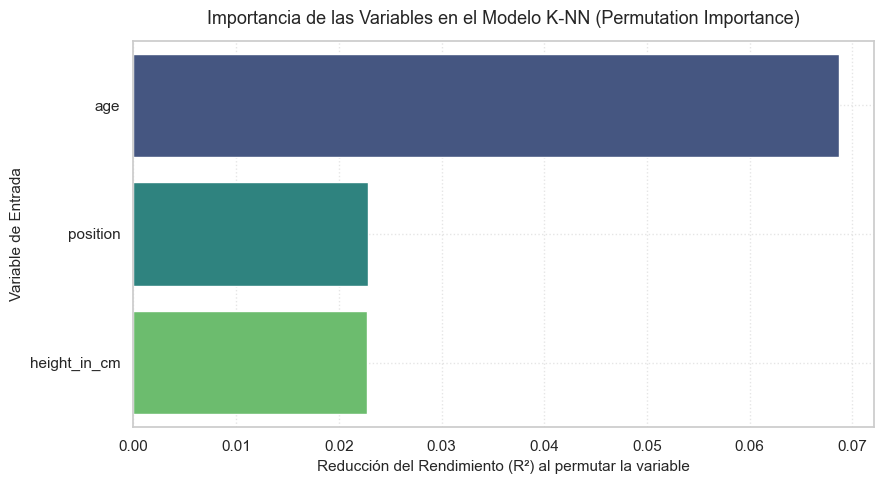

In [98]:
# Gráfico de barras de importancia (Corregido para evitar el FutureWarning)
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_importancia, 
    x='Importancia_Media', 
    y='Variable', 
    hue='Variable',          # Asignamos 'Variable' a 'hue' para mantener el color por fila
    palette='viridis', 
    legend=False             # Desactivamos la leyenda automática para que no ensucie el gráfico
)
plt.title('Importancia de las Variables en el Modelo K-NN (Permutation Importance)', fontsize=13, pad=12)
plt.xlabel('Reducción del Rendimiento (R²) al permutar la variable', fontsize=11)
plt.ylabel('Variable de Entrada', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 9. Almacenamiento Final del Modelo

In [90]:
# Guardamos el pipeline completo (.pkl) de forma segura en la raíz
filename = carpeta_models / "knn_regressor_model.pkl"
joblib.dump(pipeline_knn, filename)
#print(f"   💾 Guardado de forma absoluta en: '{filename}'\n")

['c:\\Users\\Flor\\Desktop\\Programacion\\DA-Project-Regression-Grupo2\\models\\knn_regressor_model.pkl']